   horsepower  weight   mpg
0       130.0    3504  18.0
1       165.0    3693  15.0
2       150.0    3436  18.0
3       150.0    3433  16.0
4       140.0    3449  17.0


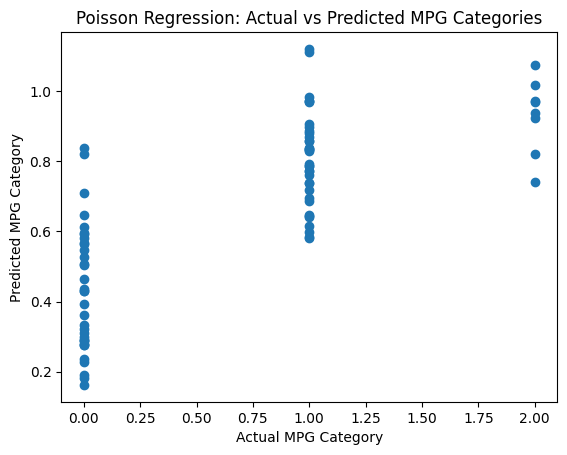

Mean Squared Error: 0.2380296168964642


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_squared_error

# Load the 'mpg' dataset from seaborn
import seaborn as sns
df = sns.load_dataset('mpg').dropna()

# For simplicity, we'll focus on 'horsepower', 'weight' and 'mpg' features
df = df[['horsepower', 'weight', 'mpg']]

# Create a target variable by discretizing the 'mpg' (treat it as a count variable)
df['mpg_category'] = pd.cut(df['mpg'], bins=3, labels=[0, 1, 2])

# Display the first few rows of the dataset to check the shape of the features
print(df[['horsepower', 'weight', 'mpg']].head())

# Features and target
X = df[['horsepower', 'weight']]  # Predicting mpg categories based on horsepower and weight
y = df['mpg_category']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Poisson regression model
model = PoissonRegressor()  # Poisson regression from scikit-learn
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Visualize the predictions vs actual values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual MPG Category')
plt.ylabel('Predicted MPG Category')
plt.title('Poisson Regression: Actual vs Predicted MPG Categories')
plt.show()

# Evaluate the model using MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


In [4]:
# New data for prediction (e.g., a car with specific weight and horsepower)
new_data = np.array([[2000, 130]])  # Example: weight=2000, horsepower=130

# Standardize the new data using the same scaler
new_data_scaled = scaler.transform(new_data)

# Predict the category of the new data point (using the logistic regression model)
predicted_category = model.predict(new_data_scaled)

# Show the predicted category
print(f"Predicted MPG Category: {predicted_category[0]}")

# Optionally, map the predicted category back to an actual MPG value if you want
category_mpg_values = {0: "Low", 1: "Medium", 2: "High"}  # Define the categories' meanings
print(f"Predicted MPG category corresponds to: {category_mpg_values[predicted_category[0]]}")


Predicted MPG Category: 2.657500833989626e-05


/Users/james/jw-workspace/machine-learning/gradient_descent_example/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


KeyError: np.float64(2.657500833989626e-05)